# Supply Chain Risk Analysis with Stardog Graph Algorithms

A global electronics company wants to know **where its supply chain is fragile**. Its network has suppliers in Asia, factories, sea ports, distribution centers, retail stores in Europe and the US, and a returns loop for refurbishment. Management asks five questions:

| # | Business question | Graph algorithm |
|---|---|---|
| 1 | Which facilities are the most critical? | **PageRank** |
| 2 | Are there parts of the business that are completely separate? | **Connected Components** |
| 3 | Where do goods flow in a closed loop (returns, refurbishment)? | **Strongly Connected Components** |
| 4 | Which facilities naturally operate as a regional cluster? | **Label Propagation** |
| 5 | Which facilities have a backup route if a link fails? | **Triangle Count** |

SPARQL is great at *local* questions ("which stores does the Chicago DC serve?"). These five are *global*: the answer for one facility depends on the shape of the whole network. That's what graph algorithms are for.

**What you'll do**

1. Explore the data and draw the network
2. Build an OWL model and load everything into Stardog
3. Run each algorithm with the **Stardog Spark connector**, then read and interpret the results
4. Combine the results into a risk table
5. Run a **what-if** analysis: add backup routes and measure the improvement

**Before you start:** select the project's `.venv` as the notebook kernel. The Spark jobs take about 15-25 seconds each.

## 1. How Stardog graph analytics works

Stardog runs graph algorithms as **Apache Spark jobs** through the *Stardog Spark connector*, a Java program (`tools/stardog-spark-connector-3.3.0.jar`) that bundles Spark itself:

```
 ┌──────────────────────── your laptop ────────────────────────┐        ┌──── Stardog Cloud ────┐
 │                                                              │        │                        │
 │  Python (this notebook)                                      │        │  database              │
 │     │ starts                                                 │        │  ├ urn:SupplyChain:data│
 │     ▼                                                        │  1.    │  │                     │
 │  java -jar stardog-spark-connector.jar  ─── CONSTRUCT query ─┼───────►│  │  (edges)            │
 │     │  (Spark in local mode)                                 │        │  │                     │
 │     │  2. runs PageRank / components / … on the edges        │  3.    │  └ urn:SupplyChain:    │
 │     └──────────────────────────── one value per node ────────┼───────►│     analytics:<Algo>   │
 └──────────────────────────────────────────────────────────────┘        └────────────────────────┘
```

1. The connector sends a **`CONSTRUCT` query** that returns the edges to analyse. We return only `facility shipsTo facility` triples, so names, cities and route details don't become part of the graph.
2. Spark runs the algorithm locally.
3. The connector writes one triple per node back to Stardog: `facility <output.property> value`, into the **`output.graph`** named graph.

Parameters are passed as `key=value` arguments:

| Parameter | Meaning |
|---|---|
| `algorithm.name` | `PageRank`, `ConnectedComponents`, `StronglyConnectedComponents`, `LabelPropagation`, `TriangleCount` |
| `algorithm.iterations` | Max iterations (default 3) |
| `stardog.server`, `stardog.database`, `stardog.username`, `stardog.password` | Where to read and write |
| `stardog.query` | `CONSTRUCT` query selecting the edges (default: all data) |
| `output.property` | Property IRI the result is stored under |
| `output.graph` | Named graph the results are written to |

**Local setup (already in `tools/`, nothing to install):**

| Item | Why |
|---|---|
| `tools/stardog-spark-connector-3.3.0.jar` | The connector, which includes Spark 3.5 |
| `tools/jdk-11…-jre` | Java 11. The connector's bundled Scala 2.12.12 crashes on Java 17 |
| `tools/hadoop/bin` (`winutils.exe`, `hadoop.dll`) | Spark on Windows needs these for checkpointing (used by Connected Components) |

## 2. Setup

The helper modules next to this notebook are reused:

- `load_data.py` builds the model and data
- `run_analytics.py` knows where Java, the connector jar and Hadoop are

In [2]:
import os
import subprocess
import tempfile

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import stardog
from dotenv import load_dotenv

import load_data
import run_analytics

load_dotenv()

conn_details = {
    'endpoint': os.environ['STARDOG_ENDPOINT'],
    'username': os.environ['STARDOG_USERNAME'],
    'password': os.environ['STARDOG_PASSWORD'],
}
DB_NAME = os.environ['STARDOG_DATABASE']
SC = 'http://example.org/supplychain#'

print('Database:', DB_NAME)
missing = run_analytics.missing_tools()
print('Missing from tools/:', ', '.join(missing) if missing else 'nothing, all set')

Database: mysampledb
Missing from tools/: nothing, all set


## 3. Explore the data

Two CSV files describe the network:

- `data/facilities.csv`: 30 facilities with type, city and region
- `data/routes.csv`: 43 directed shipping routes with transport mode and lead time

In [3]:
facilities = pd.read_csv('data/facilities.csv')
routes = pd.read_csv('data/routes.csv')
facilities.head(8)

,facility_id,name,type,city,country,region
0,S1,Shenzhen Electronics Components,Supplier,Shenzhen,China,Asia
1,S2,Shanghai Plastics Co,Supplier,Shanghai,China,Asia
2,S3,Bangalore Chip Works,Supplier,Bangalore,India,Asia
3,S4,Taipei Display Panels,Supplier,Taipei,Taiwan,Asia
4,F1,Shenzhen Assembly Plant,Factory,Shenzhen,China,Asia
5,F2,Pune Assembly Plant,Factory,Pune,India,Asia
6,P1,Port of Shanghai,Port,Shanghai,China,Asia
7,P2,Port of Singapore,Port,Singapore,Singapore,Asia


In [4]:
routes.head(8)

,from_id,to_id,mode,lead_time_days
0,S1,F1,Truck,1
1,S2,F1,Truck,2
2,S4,F1,Sea,4
3,S3,F2,Truck,2
4,S4,F2,Air,2
5,S1,F2,Air,3
6,F1,P1,Truck,2
7,F1,P2,Sea,5


In [5]:
pd.crosstab(facilities['type'], facilities['region'], margins=True)

region,Asia,Europe,North America,South America,All
type,,,,,
DistributionCenter,0,2,3,1,6
Factory,2,0,0,1,3
Port,3,1,1,0,5
RetailStore,0,3,5,2,10
ReturnsCenter,0,0,1,0,1
Supplier,4,0,0,1,5
All,9,6,10,5,30


In [6]:
routes.groupby('mode')['lead_time_days'].agg(routes='count', avg_days='mean', max_days='max').round(1)

,routes,avg_days,max_days
mode,,,
Air,2,2.5,3
Rail,2,2.5,3
Sea,10,18.7,30
Truck,29,1.7,4


### Draw the network

Facilities are laid out in columns by their role in the flow (supplier → factory → port → DC → store). The same `draw_network` function is reused later to colour and size nodes by algorithm results.

Look for the **red dashed arrow** from the Memphis returns center back to the Pune factory. That's the returns and refurbishment loop.

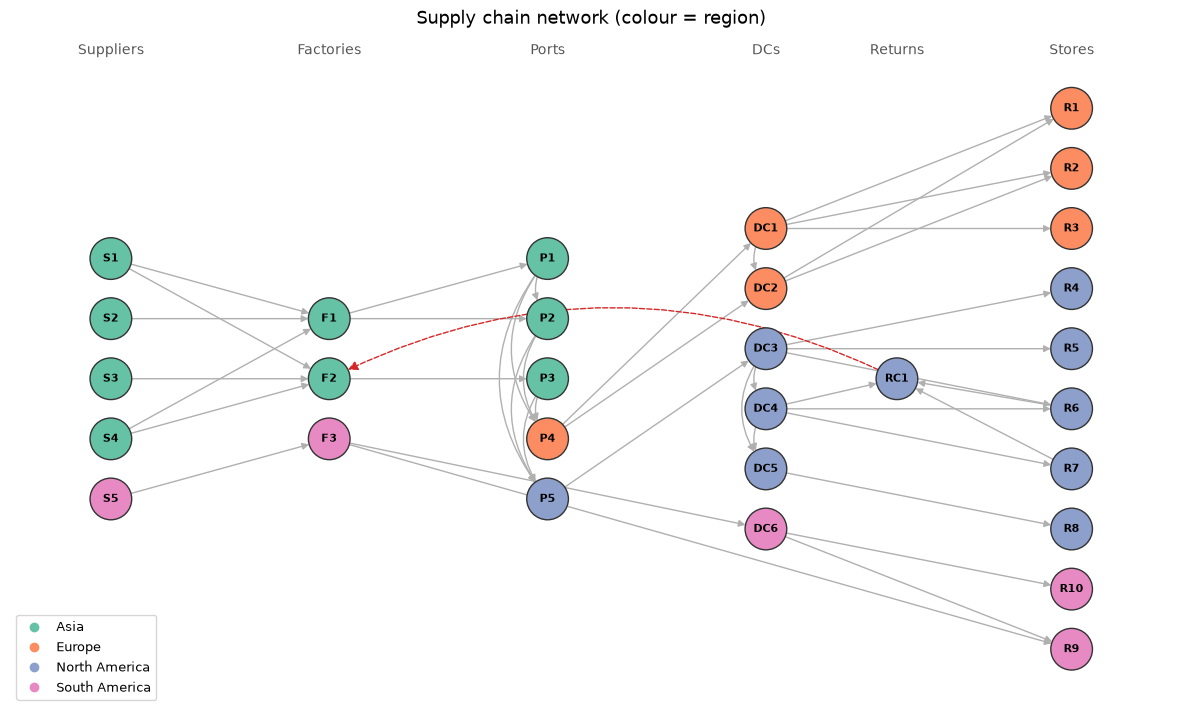

In [7]:
G = nx.DiGraph()
for f in facilities.itertuples():
    G.add_node(f.facility_id, name=f.name, type=f.type, region=f.region)
G.add_edges_from(zip(routes.from_id, routes.to_id))

LAYER = {'Supplier': 0, 'Factory': 1, 'Port': 2, 'DistributionCenter': 3, 'ReturnsCenter': 3.6, 'RetailStore': 4.4}
REGION_ORDER = {'Asia': 0, 'Europe': 1, 'North America': 2, 'South America': 3}

def layout():
    pos, columns = {}, {}
    ordered = sorted(G.nodes, key=lambda n: (REGION_ORDER[G.nodes[n]['region']], n))
    for n in ordered:
        columns.setdefault(LAYER[G.nodes[n]['type']], []).append(n)
    for x, nodes in columns.items():
        for i, n in enumerate(nodes):
            pos[n] = (x, -i + len(nodes) / 2)
    return pos

POS = layout()

def draw_network(title, colors=None, sizes=None, cmap='tab10', continuous=False, legend=None):
    '''colors: {node: value}. Categorical by default (value = index into a qualitative
    colormap); continuous=True scales numeric values across the colormap.'''
    fig, ax = plt.subplots(figsize=(15, 8.5))
    loop_edge = ('RC1', 'F2')
    same_column = [e for e in G.edges if POS[e[0]][0] == POS[e[1]][0]]
    other = [e for e in G.edges if e not in same_column and e != loop_edge]
    common = dict(ax=ax, arrowsize=10, node_size=900)
    nx.draw_networkx_edges(G, POS, edgelist=other, edge_color='#b0b0b0', **common)
    # edges within one column (e.g. port -> port) are curved so they don't run through other nodes
    nx.draw_networkx_edges(G, POS, edgelist=same_column, edge_color='#b0b0b0',
                           connectionstyle='arc3,rad=0.4', **common)
    nx.draw_networkx_edges(G, POS, edgelist=[loop_edge], edge_color='#d62728', style='dashed',
                           connectionstyle='arc3,rad=0.25', ax=ax, arrowsize=14, node_size=900)
    nodes = list(G.nodes)
    cm = plt.get_cmap(cmap)
    if colors is None:
        node_color = '#8ecae6'
    elif continuous:
        node_color = [colors[n] for n in nodes]
    else:
        node_color = [cm(colors[n] % cm.N) for n in nodes]
    nx.draw_networkx_nodes(G, POS, ax=ax, nodelist=nodes, node_color=node_color,
                           cmap=cm if continuous else None, edgecolors='#333333',
                           node_size=[sizes[n] for n in nodes] if sizes else 900)
    nx.draw_networkx_labels(G, POS, ax=ax, font_size=8, font_weight='bold')
    top = max(y for _, y in POS.values()) + 0.9
    for label, x in [('Suppliers', 0), ('Factories', 1), ('Ports', 2), ('DCs', 3), ('Returns', 3.6), ('Stores', 4.4)]:
        ax.text(x, top, label, ha='center', fontsize=10, color='#555555')
    if legend:
        ax.legend(handles=legend, loc='lower left', fontsize=9)
    ax.set_title(title, fontsize=13, pad=20)
    ax.axis('off')
    plt.show()

type_codes = {t: i for i, t in enumerate(LAYER)}
draw_network('Supply chain network (colour = region)',
             colors={n: REGION_ORDER[G.nodes[n]['region']] for n in G.nodes}, cmap='Set2',
             legend=[plt.Line2D([], [], marker='o', ls='', color=plt.get_cmap('Set2')(i), label=r)
                     for r, i in REGION_ORDER.items()])

## 4. Model the domain in RDF / OWL

`load_data.build_model()` creates the ontology (the *model*):

- **Classes:** `Facility`, with subclasses `Supplier`, `Factory`, `Port`, `DistributionCenter`, `ReturnsCenter` and `RetailStore`, plus `Route`
- **`shipsTo`**: a direct *facility → facility* edge. **This is the only relationship the algorithms see.**
- **`Route`** nodes carry the details of each shipment (`origin`, `destination`, `mode`, `leadTimeDays`). Keeping details on separate nodes stops them polluting the algorithm graph.
- **Result properties** (`pageRank`, `component`, `stronglyConnectedComponent`, `community`, `triangleCount`) are declared so they show up in Explorer

`subClassOf` means that, with reasoning on, a query for `sc:Facility` also returns every port, factory and so on.

In [8]:
model = load_data.build_model()
print(f'{len(model)} triples in the model. Excerpt:\n')
print('\n'.join(model.serialize(format='turtle').splitlines()[:40]))

78 triples in the model. Excerpt:

@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix sc: <http://example.org/supplychain#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

sc:DistributionCenter a owl:Class ;
    rdfs:label "DistributionCenter" ;
    rdfs:subClassOf sc:Facility .

sc:Factory a owl:Class ;
    rdfs:label "Factory" ;
    rdfs:subClassOf sc:Facility .

sc:Port a owl:Class ;
    rdfs:label "Port" ;
    rdfs:subClassOf sc:Facility .

sc:RetailStore a owl:Class ;
    rdfs:label "RetailStore" ;
    rdfs:subClassOf sc:Facility .

sc:ReturnsCenter a owl:Class ;
    rdfs:label "ReturnsCenter" ;
    rdfs:subClassOf sc:Facility .

sc:Supplier a owl:Class ;
    rdfs:label "Supplier" ;
    rdfs:subClassOf sc:Facility .

sc:city a owl:DatatypeProperty ;
    rdfs:label "city" ;
    rdfs:domain sc:Facility ;
    rdfs:range xsd:string .

sc:community a owl:DatatypeProperty ;
    rdfs:label "community" ;
    rdfs:domain sc

In [9]:
data = load_data.build_data()
print(f'{len(data)} data triples. One facility and one route:\n')
from rdflib import Graph, URIRef
sample = Graph()
sample.bind('sc', SC)
for s in (URIRef(SC + 'F2'), URIRef(SC + 'route_F2_P3')):
    for triple in data.triples((s, None, None)):
        sample.add(triple)
print(sample.serialize(format='turtle'))

438 data triples. One facility and one route:

@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix sc: <http://example.org/supplychain#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

sc:route_F2_P3 a sc:Route ;
    sc:destination sc:P3 ;
    sc:leadTimeDays 1 ;
    sc:mode "Truck" ;
    sc:origin sc:F2 .

sc:F2 a sc:Factory ;
    rdfs:label "Pune Assembly Plant" ;
    sc:city "Pune" ;
    sc:country "India" ;
    sc:name "Pune Assembly Plant" ;
    sc:region "Asia" ;
    sc:shipsTo sc:P3 .




## 5. Load into Stardog

We put the model and data in separate named graphs, and register the model as a **named reasoning schema** called `SupplyChain`. That's the same way Stardog Designer publishes models, and it makes the model selectable in **Stardog Explorer → Settings → Model**.

| Named graph | Contents |
|---|---|
| `urn:SupplyChain:SupplyChain` | Model |
| `urn:SupplyChain:data` | Facilities and routes |
| `urn:SupplyChain:analytics:<Algorithm>` | Algorithm results (written by Spark) |

In [10]:
with stardog.Admin(**conn_details) as admin:
    db = load_data.ensure_database(admin)   # creates the database if the server doesn't have it
    schemas = db.get_options('reasoning.schemas')['reasoning.schemas']
    schemas = [s for s in schemas if not s.startswith(f'{load_data.MODEL_NAME}=')]
    schemas.append(f'{load_data.MODEL_NAME}={load_data.MODEL_GRAPH}')
    db.set_options({'reasoning.schemas': schemas})
    print('Reasoning schemas:', schemas)

conn = stardog.Connection(DB_NAME, **conn_details)
conn.begin()
load_data.load(conn, model, load_data.MODEL_GRAPH)   # clears the graph first, then adds
load_data.load(conn, data, load_data.DATA_GRAPH)
conn.commit()
print('Loaded model and data')

Reasoning schemas: ['SupplyChain=urn:SupplyChain:SupplyChain']
Loaded model and data


A helper to run `SELECT` queries into DataFrames. `FROM <tag:stardog:api:context:all>` means "query all named graphs"; by default Stardog only searches the default graph.

In [11]:
PREFIXES = '''
PREFIX sc:   <http://example.org/supplychain#>
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd:  <http://www.w3.org/2001/XMLSchema#>
'''

def select_df(query, **kwargs):
    result = conn.select(PREFIXES + query, **kwargs)
    columns = result['head']['vars']
    rows = [{c: b[c]['value'] if c in b else None for c in columns} for b in result['results']['bindings']]
    return pd.DataFrame(rows, columns=columns)

select_df('''
SELECT ?graph (COUNT(*) AS ?triples)
WHERE { GRAPH ?graph { ?s ?p ?o } FILTER(STRSTARTS(STR(?graph), "urn:SupplyChain")) }
GROUP BY ?graph ORDER BY ?graph
''')

,graph,triples
0,urn:SupplyChain:SupplyChain,78
1,urn:SupplyChain:analytics:ConnectedComponents,30
2,urn:SupplyChain:analytics:LabelPropagation,30
3,urn:SupplyChain:analytics:PageRank,30
4,urn:SupplyChain:analytics:StronglyConnectedCom...,30
5,urn:SupplyChain:analytics:TriangleCount,30
6,urn:SupplyChain:data,438


### Warm-up: what plain SPARQL can already answer

**Reasoning in action.** No facility is typed directly as `sc:Facility`. With `reasoning=True` and the `SupplyChain` schema, Stardog infers it from `subClassOf`:

In [12]:
q = 'SELECT (COUNT(?f) AS ?facilities) FROM <urn:SupplyChain:data> WHERE { ?f a sc:Facility }'
print('Without reasoning:', select_df(q)['facilities'][0])
print('With reasoning:   ', select_df(q, reasoning=True, schema='SupplyChain')['facilities'][0])

Without reasoning: 0
With reasoning:    30


**Multi-hop reach.** Which stores ultimately depend on the Bangalore chip supplier (S3)? The property path `sc:shipsTo+` follows routes any number of hops:

In [13]:
select_df('''
SELECT ?store ?city
FROM <urn:SupplyChain:data>
WHERE {
  sc:S3 sc:shipsTo+ ?s .
  ?s a sc:RetailStore ; sc:name ?store ; sc:city ?city .
}
ORDER BY ?store
''')

,store,city
0,Amsterdam Store,Amsterdam
1,Berlin Store,Berlin
2,Chicago Store,Chicago
3,Houston Store,Houston
4,Los Angeles Store,Los Angeles
5,New York Store,New York
6,Paris Store,Paris
7,San Francisco Store,San Francisco


**Longest legs** in the network, from the `Route` detail nodes:

In [14]:
select_df('''
SELECT ?from ?to ?mode ?days
FROM <urn:SupplyChain:data>
WHERE {
  ?r a sc:Route ; sc:origin/sc:name ?from ; sc:destination/sc:name ?to ;
     sc:mode ?mode ; sc:leadTimeDays ?days .
}
ORDER BY DESC(?days) LIMIT 5
''')

,from,to,mode,days
0,Port of Shanghai,Port of Rotterdam,Sea,30
1,Memphis Returns Center,Pune Assembly Plant,Sea,30
2,Port of Mumbai,Port of Los Angeles,Sea,28
3,Port of Singapore,Port of Rotterdam,Sea,25
4,Port of Mumbai,Port of Rotterdam,Sea,22


These are *local* answers. SPARQL cannot easily say "how important is each facility **relative to the whole network**" or "which facilities form a cluster". For that we switch to graph algorithms.

## 6. Running an algorithm

`run_algorithm` builds the connector's parameters, runs it with the portable Java 11 in a temporary working directory (Spark leaves checkpoint files behind), and prints only the connector's summary lines. The full Spark log is very noisy.

It also first clears the output graph, so rerunning a cell doesn't leave duplicate results.

`EDGES_QUERY` is the `CONSTRUCT` query that tells the connector which edges to analyse.

In [15]:
EDGES_QUERY = (f'construct {{ ?s <{SC}shipsTo> ?o }} '
               f'from <urn:SupplyChain:data> where {{ ?s <{SC}shipsTo> ?o }}')

def run_algorithm(algorithm, output_property, output_graph, edges_query=EDGES_QUERY, iterations=10):
    conn.begin()
    conn.clear(graph_uri=output_graph)          # always pass graph_uri!
    conn.commit()

    params = [
        f'algorithm.name={algorithm}',
        f'algorithm.iterations={iterations}',
        f'stardog.server={conn_details["endpoint"]}',
        f'stardog.database={DB_NAME}',
        f'stardog.username={conn_details["username"]}',
        f'stardog.password={conn_details["password"]}',
        f'stardog.query={edges_query}',
        f'output.property={SC}{output_property}',
        f'output.graph={output_graph}',
    ]
    cmd = [str(run_analytics.java_binary()), *run_analytics.JAVA_OPTS, '-jar', str(run_analytics.CONNECTOR_JAR), *params]
    with tempfile.TemporaryDirectory() as workdir:
        proc = subprocess.run(cmd, env=run_analytics.ENV, cwd=workdir, capture_output=True, text=True)
    log = (proc.stdout + proc.stderr).splitlines()
    if proc.returncode != 0:
        # never print cmd: it contains the password
        raise RuntimeError(f'{algorithm} failed:\n' + '\n'.join(log[-25:]))
    print('\n'.join(l for l in log if l.startswith(('Starting', 'Added', 'Finished'))))


def results(output_property, graph):
    df = select_df(f'''
    SELECT ?id ?name ?type ?region ?value
    WHERE {{
      GRAPH <{graph}> {{ ?f sc:{output_property} ?value }}
      GRAPH <urn:SupplyChain:data> {{ ?f sc:name ?name ; sc:region ?region ; a ?t }}
      BIND(STRAFTER(STR(?f), '#') AS ?id)
      BIND(STRAFTER(STR(?t), '#') AS ?type)
    }}''')
    df['value'] = pd.to_numeric(df['value'])
    return df.rename(columns={'value': output_property})

def graph_for(algorithm):
    return f'urn:SupplyChain:analytics:{algorithm}'

## 7. PageRank: which facilities are the most critical?

**Idea.** PageRank was invented to rank web pages. A page is important if important pages link to it. Picture a "random shipment" that keeps following routes. PageRank is the share of time it spends at each facility. With a small probability (the *damping factor*, usually 15%) it jumps to a random facility, so dead ends don't trap it.

**In a supply chain,** a high PageRank means many flows, including flows from other important facilities, **converge** on that facility. A disruption there propagates the furthest.

**Direction matters.** Rank flows *along* `shipsTo`, so downstream facilities collect it.

In [16]:
run_algorithm('PageRank', 'pageRank', graph_for('PageRank'), iterations=20)
pagerank = results('pageRank', graph_for('PageRank')).sort_values('pageRank', ascending=False)
pagerank.head(10).round(3)

Starting PageRank
Added 30 triples (ignored: 0)
Finished PageRank in 15.14 s


,id,name,type,region,pageRank
21,F2,Pune Assembly Plant,Factory,Asia,2.303
20,P3,Port of Mumbai,Port,Asia,2.303
6,DC3,Los Angeles Distribution Center,DistributionCenter,North America,1.992
24,P5,Port of Los Angeles,Port,North America,1.938
23,P4,Port of Rotterdam,Port,Europe,1.938
12,RC1,Memphis Returns Center,ReturnsCenter,North America,1.613
0,DC2,Frankfurt Distribution Center,DistributionCenter,Europe,1.417
2,R1,Berlin Store,RetailStore,Europe,1.196
3,R2,Paris Store,RetailStore,Europe,1.196
1,DC1,Rotterdam Distribution Center,DistributionCenter,Europe,1.169


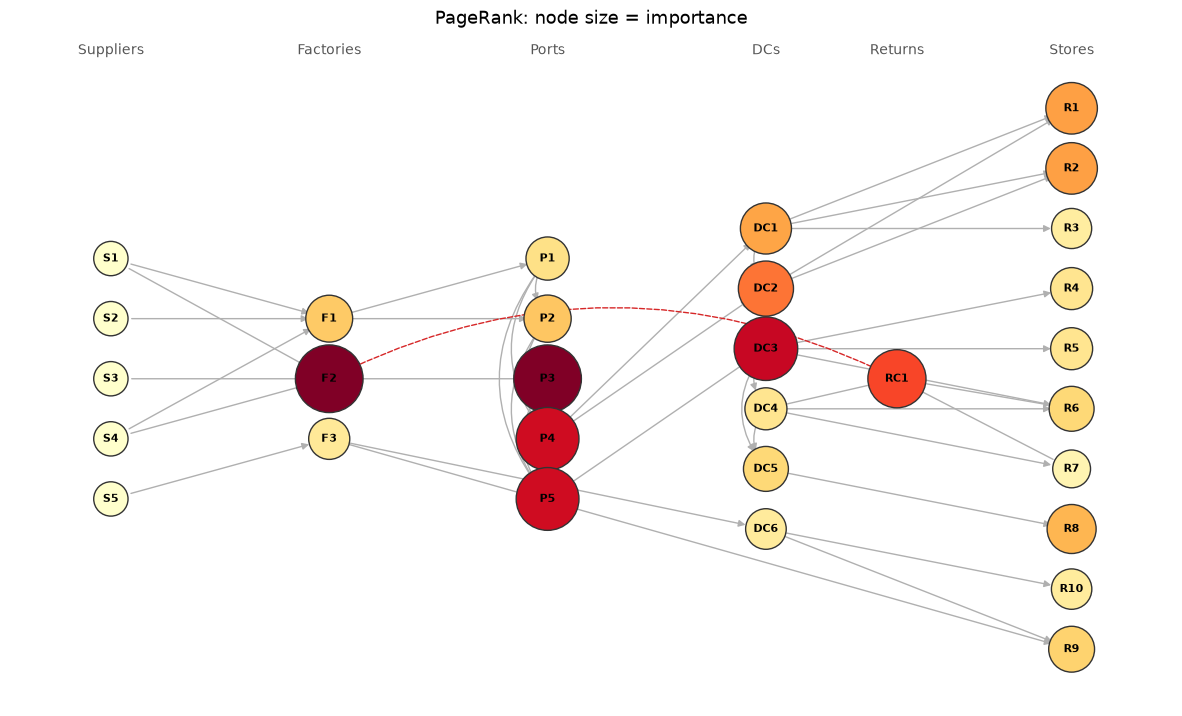

In [17]:
pr = dict(zip(pagerank.id, pagerank.pageRank))
draw_network('PageRank: node size = importance', colors={n: pr[n] for n in G.nodes},
             sizes={n: 300 + 900 * pr[n] for n in G.nodes}, cmap='YlOrRd', continuous=True)

**Interpretation**

- **Pune Assembly Plant (F2)** and **Port of Mumbai (P3)** come out on top. That's not because they're big, but because the **returns loop** (US stores → Memphis → Pune) feeds rank back into them. Everything that goes around the loop passes through F2 and then P3.
- **LA DC, the LA port and the Rotterdam port** are the gateways into the two main markets.
- Suppliers score lowest: nothing flows *into* them.

## 8. Connected Components: are there separate networks?

**Idea.** Two facilities are in the same component if you can get from one to the other along routes, **ignoring direction**. Each component gets an ID. All members share it, and the value itself has no meaning.

**In a supply chain,** separate components are business units that share no logistics. Problems in one can't spread to the other, but neither can they share capacity.

In [18]:
run_algorithm('ConnectedComponents', 'component', graph_for('ConnectedComponents'))
components = results('component', graph_for('ConnectedComponents'))
components.groupby('component').agg(facilities=('id', 'count'),
                                    regions=('region', lambda r: ', '.join(sorted(set(r)))))

Starting ConnectedComponents
Added 30 triples (ignored: 0)
Finished ConnectedComponents in 26.27 s


,facilities,regions
component,,
0,25,"Asia, Europe, North America"
7,5,South America


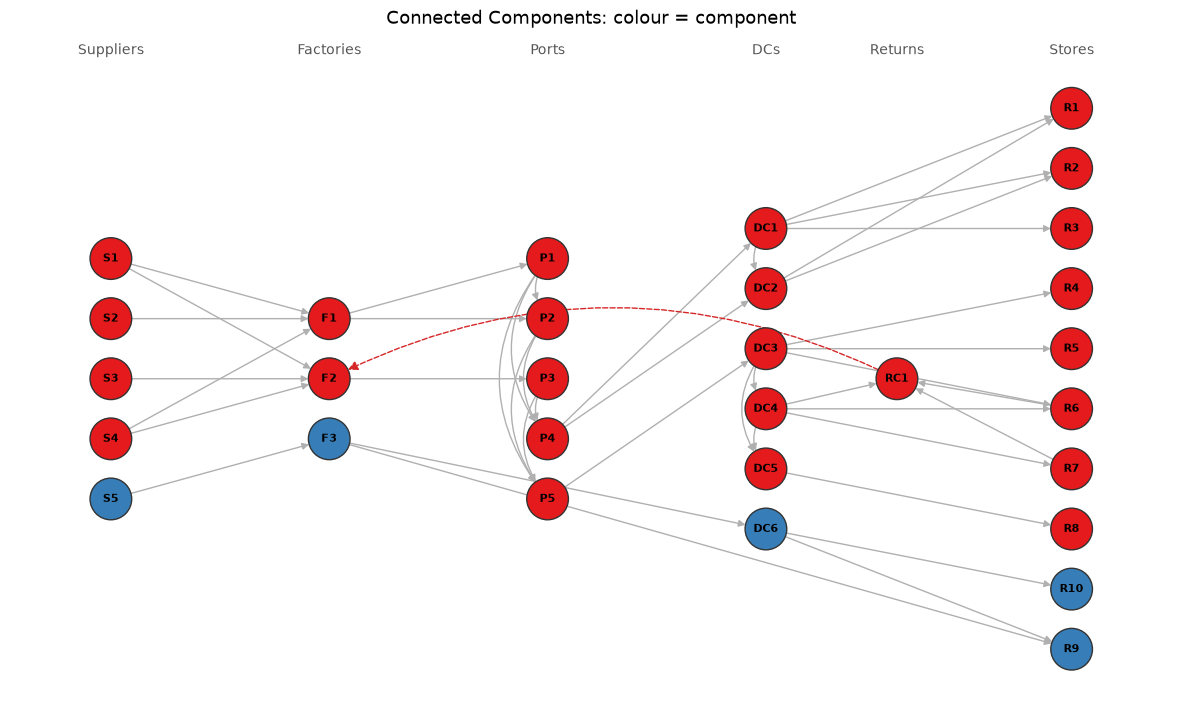

In [19]:
codes = {c: i for i, c in enumerate(components.component.unique())}
cc = {r.id: codes[r.component] for r in components.itertuples()}
draw_network('Connected Components: colour = component', colors=cc, cmap='Set1')

**Interpretation.** Two networks: the global electronics chain (Asia, Europe, North America) and the **South American coffee chain**, which shares no routes with it. A port strike in Rotterdam can't affect the coffee business, and the coffee business can't borrow capacity from the electronics network either.

## 9. Strongly Connected Components: where are the closed loops?

**Idea.** Like connected components, but **direction matters**. Facilities are in the same strongly connected component (SCC) only if each can reach the other *following route directions*. In a normal one-way supply chain every facility is its own SCC. An SCC with several members is a **cycle**.

**In a supply chain,** cycles are returns, refurbishment or re-export loops. They matter because goods and problems can **circulate**: a quality defect at the factory comes back as returns, which go back to the factory.

In [20]:
run_algorithm('StronglyConnectedComponents', 'stronglyConnectedComponent', graph_for('StronglyConnectedComponents'))
scc = results('stronglyConnectedComponent', graph_for('StronglyConnectedComponents'))
sizes = scc.groupby('stronglyConnectedComponent')['id'].transform('count')
loop = scc[sizes > 1].sort_values('id')
print(f'{scc.stronglyConnectedComponent.nunique()} SCCs; {len(loop)} facilities are in a loop:')
loop[['id', 'name', 'type']]

Starting StronglyConnectedComponents
Added 30 triples (ignored: 0)
Finished StronglyConnectedComponents in 17.76 s
23 SCCs; 8 facilities are in a loop:


,id,name,type
6,DC3,Los Angeles Distribution Center,DistributionCenter
5,DC4,Chicago Distribution Center,DistributionCenter
21,F2,Pune Assembly Plant,Factory
20,P3,Port of Mumbai,Port
24,P5,Port of Los Angeles,Port
10,R6,Chicago Store,RetailStore
11,R7,New York Store,RetailStore
12,RC1,Memphis Returns Center,ReturnsCenter


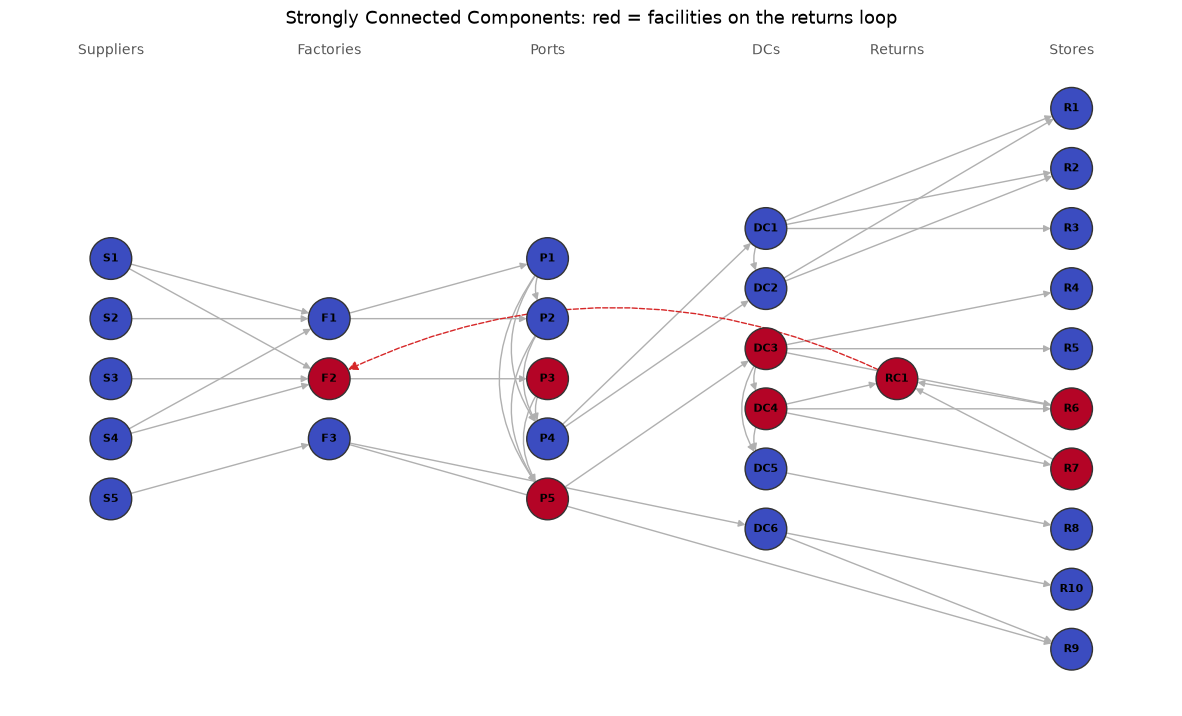

In [21]:
in_loop = set(loop.id)
draw_network('Strongly Connected Components: red = facilities on the returns loop',
             colors={n: 1 if n in in_loop else 0 for n in G.nodes}, cmap='coolwarm', continuous=True)

**Interpretation.** One loop with 8 facilities: **Pune plant → Mumbai port → LA port → LA DC → Chicago DC → Chicago and New York stores → Memphis returns center → Pune plant**. Everything else flows one way. This loop is also why F2 and P3 top the PageRank.

## 10. Label Propagation: natural logistics clusters

**Idea.** Every facility starts with its own label. In each iteration, each facility adopts the label that is most common among its neighbours. Densely connected groups quickly converge on a shared label. These are the **communities**.

**In a supply chain,** communities show which facilities *operate together* in practice, whatever the org chart says. They're useful for regional planning, inventory pooling and deciding where to put a planner.

**Caveat.** Label Propagation is fast but **not deterministic**: ties are broken arbitrarily, so results can differ slightly between runs, and small groups can split. Treat it as exploratory.

In [22]:
run_algorithm('LabelPropagation', 'community', graph_for('LabelPropagation'))
communities = results('community', graph_for('LabelPropagation'))
(communities.sort_values('id')
            .groupby('community')
            .agg(size=('id', 'count'), members=('id', ', '.join), regions=('region', lambda r: ', '.join(sorted(set(r)))))
            .sort_values('size', ascending=False))

Starting LabelPropagation
Added 30 triples (ignored: 0)
Finished LabelPropagation in 13.94 s


,size,members,regions
community,,,
2,12,"DC3, DC4, DC5, P1, P2, P3, R4, R5, R6, R7, R8,...","Asia, North America"
11,4,"F1, F2, P4, P5","Asia, Europe, North America"
29,4,"S1, S2, S3, S4",Asia
17,3,"DC6, R9, S5",South America
26,3,"R1, R2, R3",Europe
18,2,"DC1, DC2",Europe
31,2,"F3, R10",South America


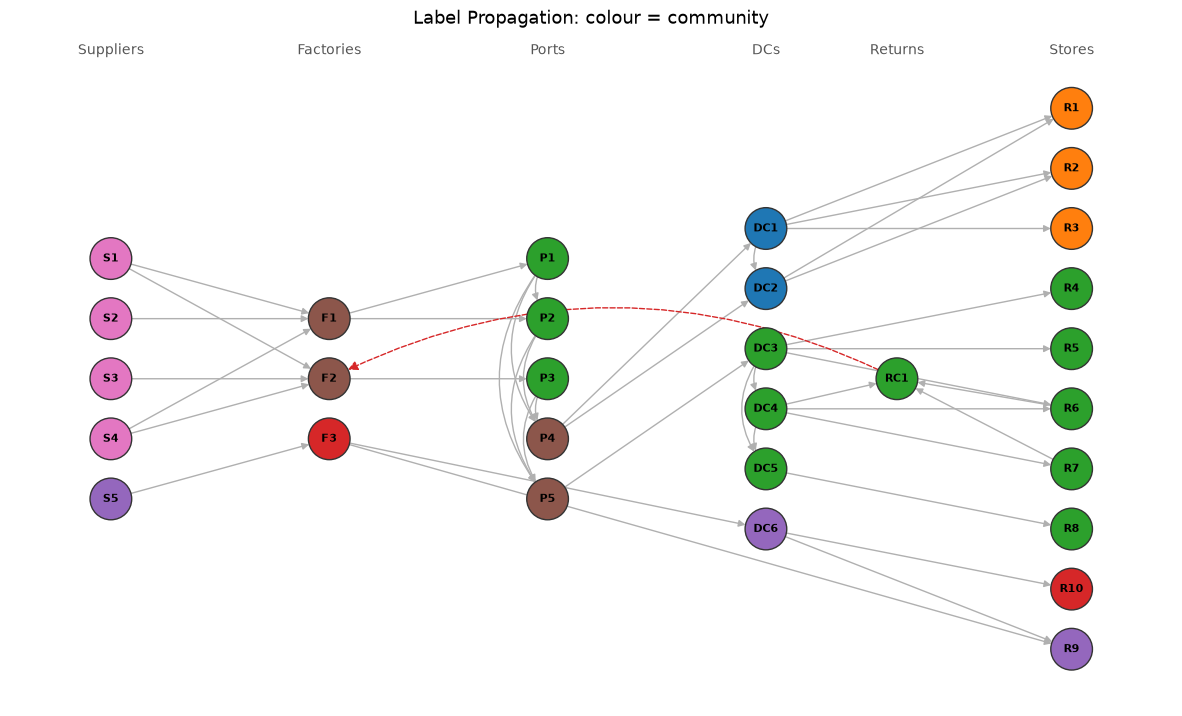

In [23]:
codes = {c: i for i, c in enumerate(communities.community.unique())}
lp = {r.id: codes[r.community] for r in communities.itertuples()}
draw_network('Label Propagation: colour = community', colors=lp, cmap='tab10')

**Interpretation.** The clearest community is the **US distribution network** (the LA, Chicago and Dallas DCs, their stores, and the returns center). It also pulls in the Asian export ports that feed it. The European stores and the Asian suppliers form their own groups. The Rotterdam/Frankfurt DCs are a tight pair that serves the European stores.

## 11. Triangle Count: who has a backup route?

**Idea.** A triangle is three facilities that are all connected to each other (ignoring direction). The algorithm counts how many triangles each facility is part of.

**In a supply chain,** a triangle A–B–C means that if the A–B link fails, goods can still go A–C–B. Triangles are **local redundancy**. A hub with **zero triangles** has no short detour: it's a single point of failure.

In [24]:
run_algorithm('TriangleCount', 'triangleCount', graph_for('TriangleCount'), iterations=1)
triangles = results('triangleCount', graph_for('TriangleCount')).sort_values('triangleCount', ascending=False)
triangles.head(10)

Starting TriangleCount
Added 30 triples (ignored: 0)
Finished TriangleCount in 14.70 s


,id,name,type,region,triangleCount
5,DC4,Chicago Distribution Center,DistributionCenter,North America,4
0,DC2,Frankfurt Distribution Center,DistributionCenter,Europe,3
1,DC1,Rotterdam Distribution Center,DistributionCenter,Europe,3
17,P1,Port of Shanghai,Port,Asia,3
19,P2,Port of Singapore,Port,Asia,3
12,RC1,Memphis Returns Center,ReturnsCenter,North America,2
10,R6,Chicago Store,RetailStore,North America,2
23,P4,Port of Rotterdam,Port,Europe,2
6,DC3,Los Angeles Distribution Center,DistributionCenter,North America,2
11,R7,New York Store,RetailStore,North America,1


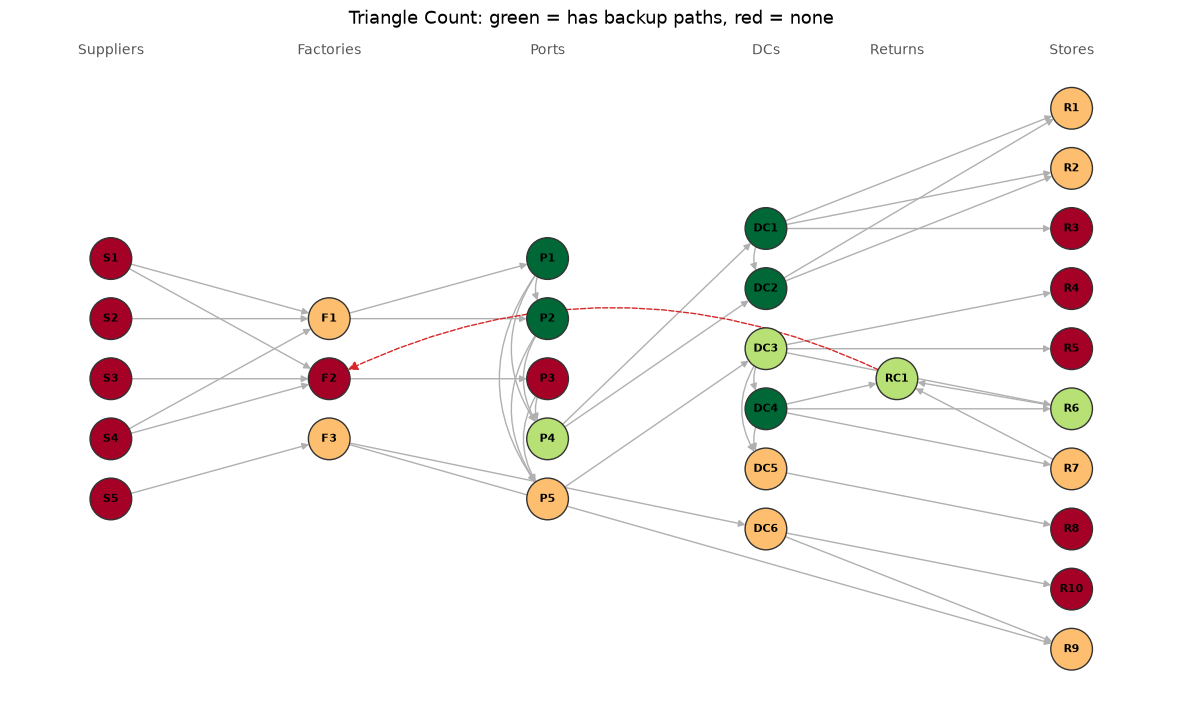

In [25]:
tc = dict(zip(triangles.id, triangles.triangleCount))
draw_network('Triangle Count: green = has backup paths, red = none',
             colors={n: min(tc[n], 3) for n in G.nodes}, cmap='RdYlGn', continuous=True)

**Interpretation.** The European DCs (Rotterdam, Frankfurt), the Chicago DC and the Shanghai/Singapore ports sit in several triangles: they have alternatives. **Pune (F2) and Mumbai (P3) have zero.** Pune ships *only* via Mumbai, and Mumbai has no link to another port.

## 12. Putting it together: a risk table

A facility is a **high risk** when it is **important** (high PageRank) **and fragile** (no triangles). We join the results of all five algorithms into one table.

In [26]:
summary = (pagerank[['id', 'name', 'type', 'pageRank']]
           .merge(triangles[['id', 'triangleCount']], on='id')
           .merge(scc[['id', 'stronglyConnectedComponent']], on='id'))
summary['onReturnsLoop'] = summary.id.isin(in_loop)
summary['risk'] = 'low'
summary.loc[summary.pageRank >= summary.pageRank.quantile(0.6), 'risk'] = 'medium'
summary.loc[(summary.pageRank >= summary.pageRank.quantile(0.6)) & (summary.triangleCount == 0), 'risk'] = 'HIGH'
summary = summary.drop(columns='stronglyConnectedComponent').sort_values('pageRank', ascending=False)
summary.head(12).round(3)

,id,name,type,pageRank,triangleCount,onReturnsLoop,risk
0,F2,Pune Assembly Plant,Factory,2.303,0,True,HIGH
1,P3,Port of Mumbai,Port,2.303,0,True,HIGH
2,DC3,Los Angeles Distribution Center,DistributionCenter,1.992,2,True,medium
3,P5,Port of Los Angeles,Port,1.938,1,True,medium
4,P4,Port of Rotterdam,Port,1.938,2,False,medium
5,RC1,Memphis Returns Center,ReturnsCenter,1.613,2,True,medium
6,DC2,Frankfurt Distribution Center,DistributionCenter,1.417,3,False,medium
7,R1,Berlin Store,RetailStore,1.196,1,False,medium
8,R2,Paris Store,RetailStore,1.196,1,False,medium
9,DC1,Rotterdam Distribution Center,DistributionCenter,1.169,3,False,medium


**Finding.** **Pune Assembly Plant (F2)** and **Port of Mumbai (P3)** are the most important facilities **and** have no backup route. Losing either stops the Indian production line *and* breaks the returns loop.

## 13. What-if: add backup routes

Suppose the company adds two new sea routes:

- **Pune plant → Port of Singapore** (`F2 → P2`)
- **Mumbai → Singapore feeder** (`P3 → P2`)

That creates a triangle F2–P3–P2, so Pune has a second way out. We store the new routes in a separate **what-if graph** and rerun the algorithms on *data + what-if*. The real data isn't changed.

This is a big advantage of the connector's `stardog.query` parameter: the algorithm runs on whatever the `CONSTRUCT` returns, so scenarios are just extra named graphs.

In [27]:
WHATIF_GRAPH = 'urn:SupplyChain:whatif'

conn.begin()
conn.clear(graph_uri=WHATIF_GRAPH)
conn.commit()
conn.update(PREFIXES + f'''
INSERT DATA {{ GRAPH <{WHATIF_GRAPH}> {{
  sc:F2 sc:shipsTo sc:P2 .
  sc:P3 sc:shipsTo sc:P2 .
}} }}''')

WHATIF_EDGES = (f'construct {{ ?s <{SC}shipsTo> ?o }} '
                f'from <urn:SupplyChain:data> from <{WHATIF_GRAPH}> where {{ ?s <{SC}shipsTo> ?o }}')

run_algorithm('TriangleCount', 'triangleCount', f'{WHATIF_GRAPH}:TriangleCount', WHATIF_EDGES, iterations=1)
run_algorithm('PageRank', 'pageRank', f'{WHATIF_GRAPH}:PageRank', WHATIF_EDGES, iterations=20)

Starting TriangleCount
Added 30 triples (ignored: 0)
Finished TriangleCount in 13.11 s
Starting PageRank
Added 30 triples (ignored: 0)
Finished PageRank in 16.50 s


In [28]:
after = (results('pageRank', f'{WHATIF_GRAPH}:PageRank')[['id', 'pageRank']]
         .merge(results('triangleCount', f'{WHATIF_GRAPH}:TriangleCount')[['id', 'triangleCount']], on='id'))
compare = summary[['id', 'name', 'pageRank', 'triangleCount']].merge(after, on='id', suffixes=(' before', ' after'))
compare[compare.id.isin(['F2', 'P3', 'P2', 'P5', 'P4'])].set_index('id').round(3)

,name,pageRank before,triangleCount before,pageRank after,triangleCount after
id,,,,,
F2,Pune Assembly Plant,2.303,0,2.283,1
P3,Port of Mumbai,2.303,0,1.313,3
P5,Port of Los Angeles,1.938,1,1.896,2
P4,Port of Rotterdam,1.938,2,1.896,3
P2,Port of Singapore,0.951,3,2.287,6


**Result.**

- Pune (F2) and Mumbai (P3) now sit in triangles, so they're **no longer single points of failure**.
- Mumbai's PageRank drops sharply because flow is now split between two ports, so it is less critical.
- Singapore (P2) picks up that PageRank as the new alternative gateway. The company should make sure Singapore has the capacity.
- Pune itself stays highly ranked, because the returns loop still ends there. The same approach can test any scenario: closing a port, adding a DC, rerouting a lane.

## 14. Explore the results in Stardog

All results are stored in Stardog. In **Stardog Studio** you can query them together with the data:

```sparql
PREFIX sc: <http://example.org/supplychain#>
SELECT ?name ?rank ?triangles
FROM <tag:stardog:api:context:all>
WHERE {
  ?f sc:name ?name ; sc:pageRank ?rank ; sc:triangleCount ?triangles .
}
ORDER BY DESC(?rank)
```

In **Stardog Explorer**, open *Settings → Model → SupplyChain* to browse facilities, routes and the result properties.

## 15. Clean up

The what-if graphs are temporary, so remove them. The main results stay in `urn:SupplyChain:analytics:*` for Studio and Explorer.

In [29]:
conn.begin()
for g in (WHATIF_GRAPH, f'{WHATIF_GRAPH}:TriangleCount', f'{WHATIF_GRAPH}:PageRank'):
    conn.clear(graph_uri=g)                   # always with graph_uri
conn.commit()
conn.close()
print('What-if graphs removed, connection closed')

What-if graphs removed, connection closed


## Summary

| Algorithm | Direction | Output | Supply chain use |
|---|---|---|---|
| PageRank | directed | score per facility | criticality: where disruption spreads furthest |
| Connected Components | undirected | component ID | independent business networks |
| Strongly Connected Components | directed | component ID | returns, refurbishment and re-export loops |
| Label Propagation | undirected | community ID | natural operating clusters (exploratory) |
| Triangle Count | undirected | count | local redundancy, single points of failure |

**Key takeaways**

- Keep the **algorithm graph clean**: pass only the relevant edges with `stardog.query`, and put details on separate nodes.
- Results come back as **ordinary triples**, so they can be joined with the business data in SPARQL.
- **Scenarios are just named graphs**: add or remove edges in a what-if graph and rerun.
- Combining algorithms (importance × redundancy) gives far better insight than any single one.

**Scripts version:** `load_data.py` → `run_analytics.py` → `report.py` run the same pipeline without the notebook.